<a href="https://colab.research.google.com/github/kzuhayr/MIT-URTC-Paper/blob/main/MIT_URTC_Paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd

# Main indicators I'm using. Gold is the targe and rest are features
# Added TYX (10yr treasury yield) because gold is sensitive to real interest rates
tickers = {
    "Gold": "GC=F",
    "USD_Index": "DX-Y.NYB",
    "SP500": "^GSPC",
    "Oil": "CL=F",
    "VIX": "^VIX",
    "Treasury_Yield": "^TYX"
}

# downloading each ticker separately because yfinance was giving weird column errors when downloading all at once
raw = {}
for name, tick in tickers.items():
    temp = yf.download(tick, start="2015-01-01", end="2025-01-01", auto_adjust=True)
    if isinstance(temp.columns, pd.MultiIndex):
        temp.columns = temp.columns.get_level_values(0)
    raw[name] = temp["Close"]

df = pd.DataFrame(raw).dropna()
print(df.shape)
df.tail()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


(2513, 6)


,Gold,USD_Index,SP500,Oil,VIX,Treasury_Yield
Date,,,,,,
2024-12-24,2620.000000,108.260002,6040.040039,70.099998,14.27,4.765
2024-12-26,2638.800049,108.129997,6037.589844,69.620003,14.73,4.762
2024-12-27,2617.199951,108.000000,5970.839844,70.599998,15.95,4.811
2024-12-30,2606.100098,108.129997,5906.939941,70.989998,17.40,4.763
2024-12-31,2629.199951,108.489998,5881.629883,71.720001,17.35,4.786


(2453, 12)
train: 2015-03-31 to 2023-01-18
test: 2023-01-19 to 2024-12-31


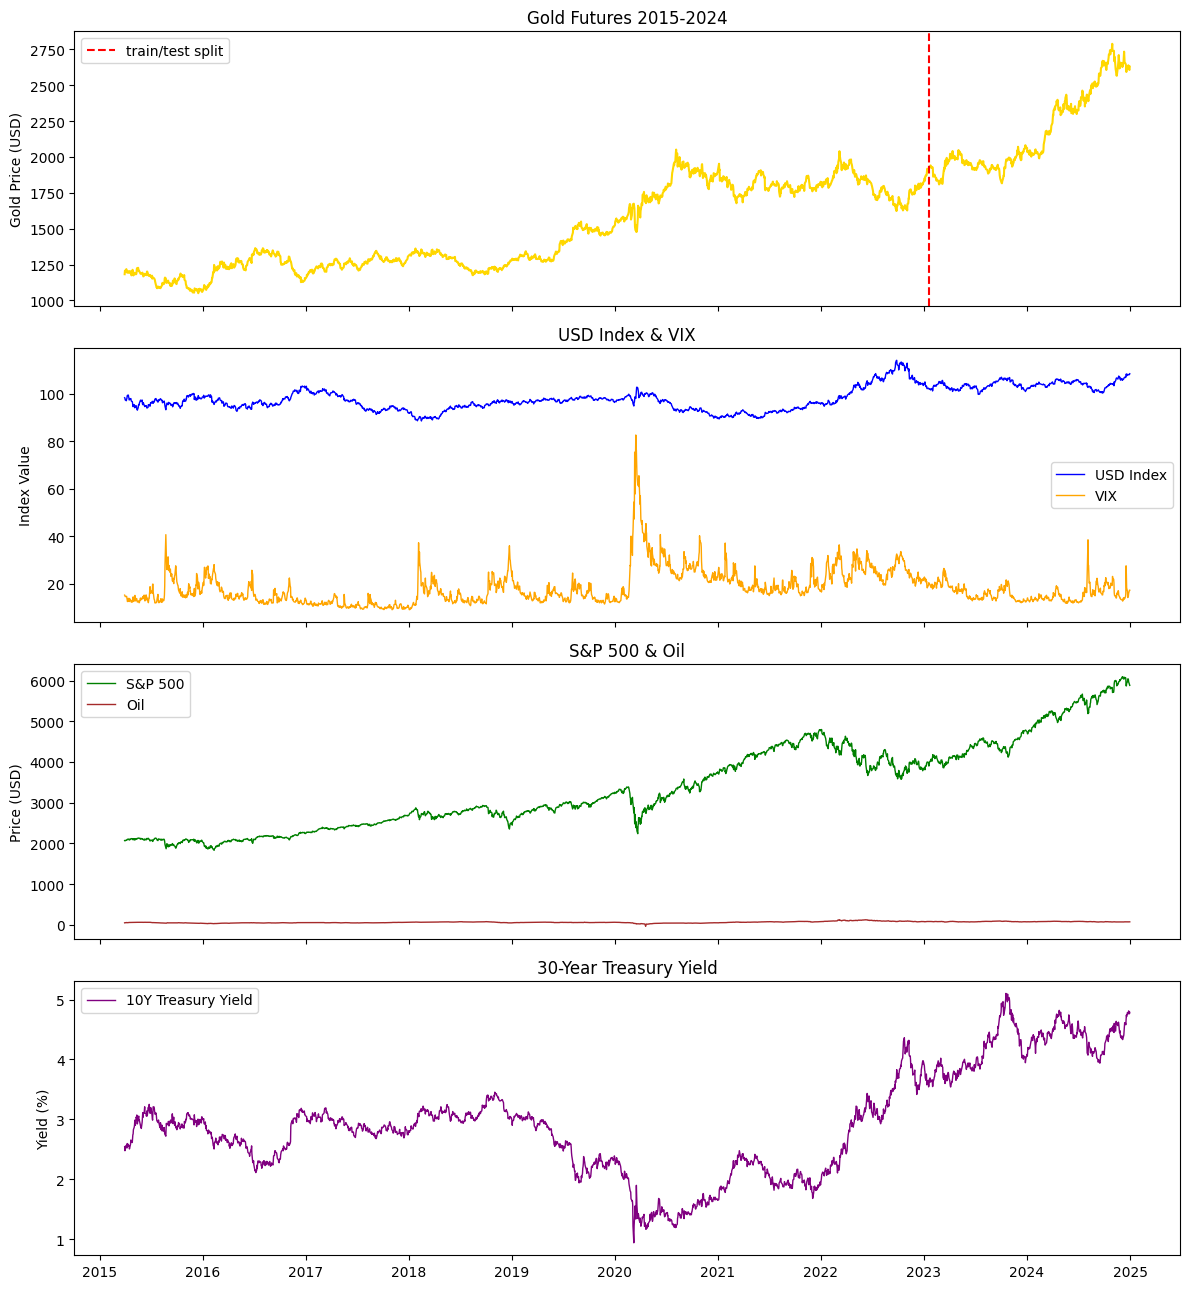

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df = df.ffill()

# Lag features
df['Gold_Lag1'] = df['Gold'].shift(1)
df['Gold_Lag5'] = df['Gold'].shift(5)
df['Gold_Lag30'] = df['Gold'].shift(30)

# Rolling averages to capture short and medium term trends
df['Gold_MA7'] = df['Gold'].rolling(7).mean()
df['Gold_MA30'] = df['Gold'].rolling(30).mean()
df['Gold_Volatility'] = df['Gold'].rolling(30).std()

df = df.dropna()
print(df.shape)

# Splitting by time n not randomly otherwise future data leaks into training
split = int(len(df) * 0.8)
train = df.iloc[:split]
test = df.iloc[split:]
print(f"train: {train.index[0].date()} to {train.index[-1].date()}")
print(f"test: {test.index[0].date()} to {test.index[-1].date()}")

fig, axes = plt.subplots(4, 1, figsize=(12, 13), sharex=True)

axes[0].plot(df.index, df['Gold'], color='gold', linewidth=1.5)
axes[0].axvline(df.index[split], color='red', linestyle='--', label='train/test split')
axes[0].set_ylabel('Gold Price (USD)')
axes[0].set_title('Gold Futures 2015-2024')
axes[0].legend()

axes[1].plot(df.index, df['USD_Index'], color='blue', linewidth=1, label='USD Index')
axes[1].plot(df.index, df['VIX'], color='orange', linewidth=1, label='VIX')
axes[1].set_ylabel('Index Value')
axes[1].set_title('USD Index & VIX')
axes[1].legend()

axes[2].plot(df.index, df['SP500'], color='green', linewidth=1, label='S&P 500')
axes[2].plot(df.index, df['Oil'], color='brown', linewidth=1, label='Oil')
axes[2].set_ylabel('Price (USD)')
axes[2].set_title('S&P 500 & Oil')
axes[2].legend()

axes[3].plot(df.index, df['Treasury_Yield'], color='purple', linewidth=1, label='10Y Treasury Yield')
axes[3].set_ylabel('Yield (%)')
axes[3].set_title('30-Year Treasury Yield')
axes[3].legend()

plt.tight_layout()
plt.savefig('eda_plot.png', dpi=150)
plt.show()

Fitting ARIMA... (may take 30–60 seconds)

── ARIMA(5,1,0) Results ──
RMSE: 408.54
MAE:  304.49
MAPE: 12.74%


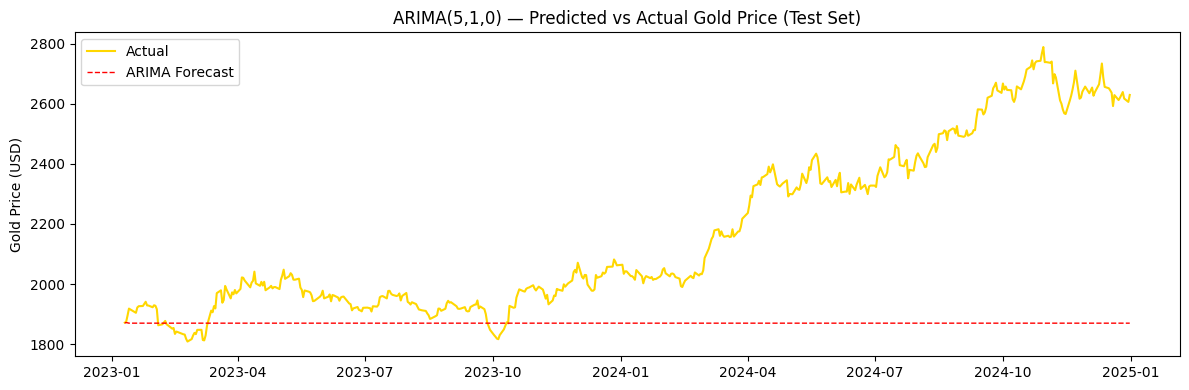

In [ ]:
# TESTING WITH ARIMA

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ARIMA works on the raw Gold price series
train_gold = train['Gold']
test_gold  = test['Gold']

# Fit ARIMA(5,1,0) — standard for financial time series
print("Fitting ARIMA... (may take 30–60 seconds)")
arima_model = ARIMA(train_gold, order=(5, 1, 0))
arima_result = arima_model.fit()

# Forecast on test set
arima_preds = arima_result.forecast(steps=len(test_gold))
arima_preds.index = test_gold.index  # align dates

# Evaluate
arima_rmse = np.sqrt(mean_squared_error(test_gold, arima_preds))
arima_mae  = mean_absolute_error(test_gold, arima_preds)
arima_mape = np.mean(np.abs((test_gold.values - arima_preds.values) / test_gold.values)) * 100

print(f"\n── ARIMA(5,1,0) Results ──")
print(f"RMSE: {arima_rmse:.2f}")
print(f"MAE:  {arima_mae:.2f}")
print(f"MAPE: {arima_mape:.2f}%")

# Plot
plt.figure(figsize=(12, 4))
plt.plot(test_gold.index, test_gold.values, label='Actual', color='gold', linewidth=1.5)
plt.plot(test_gold.index, arima_preds.values, label='ARIMA Forecast', color='red', linewidth=1, linestyle='--')
plt.title('ARIMA(5,1,0) — Predicted vs Actual Gold Price (Test Set)')
plt.ylabel('Gold Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('arima_plot.png', dpi=150)
plt.show()

── XGBoost Results ──
RMSE: 369.89
MAE:  259.53
MAPE: 10.69%


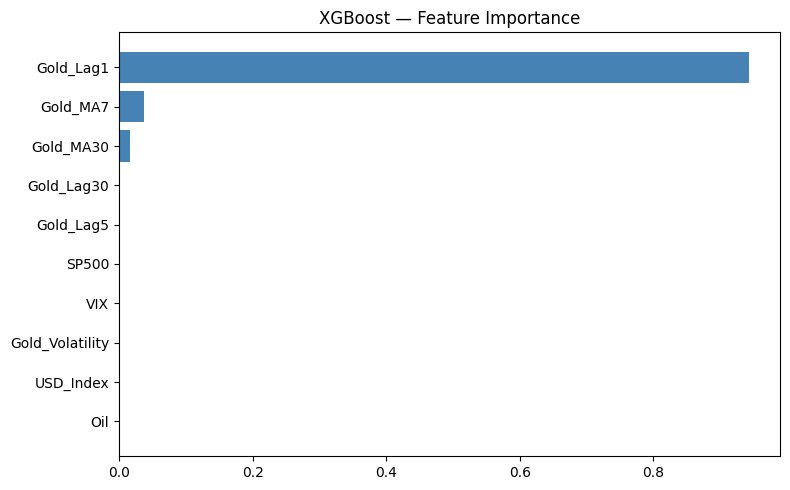

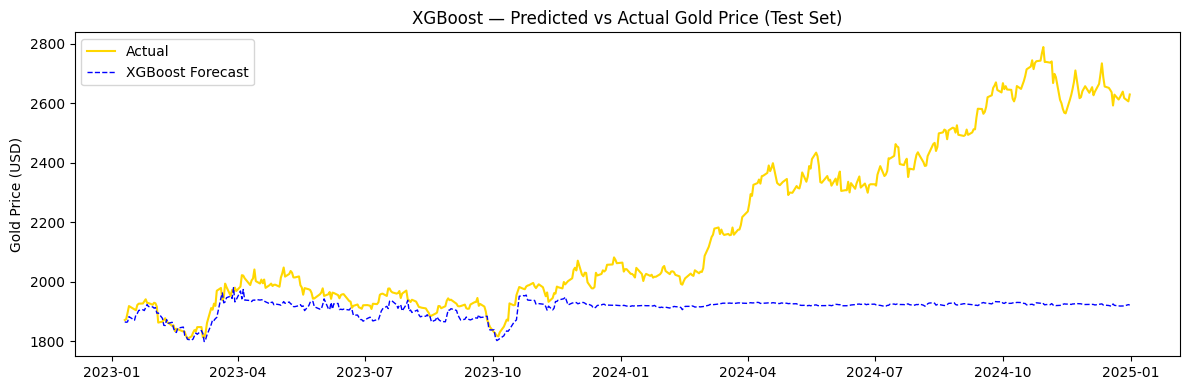

In [ ]:
# TESTING WITH XGBOOST

from xgboost import XGBRegressor

features = ['USD_Index', 'SP500', 'Oil', 'VIX',
            'Gold_Lag1', 'Gold_Lag5', 'Gold_Lag30',
            'Gold_MA7', 'Gold_MA30', 'Gold_Volatility']

X_train = train[features]
y_train = train['Gold']
X_test  = test[features]
y_test  = test['Gold']

# Train XGBoost
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# Evaluate
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mae  = mean_absolute_error(y_test, xgb_preds)
xgb_mape = np.mean(np.abs((y_test.values - xgb_preds) / y_test.values)) * 100

print(f"── XGBoost Results ──")
print(f"RMSE: {xgb_rmse:.2f}")
print(f"MAE:  {xgb_mae:.2f}")
print(f"MAPE: {xgb_mape:.2f}%")

# Feature importance plot
plt.figure(figsize=(8, 5))
importance = xgb_model.feature_importances_
sorted_idx = np.argsort(importance)
plt.barh([features[i] for i in sorted_idx], importance[sorted_idx], color='steelblue')
plt.title('XGBoost — Feature Importance')
plt.tight_layout()
plt.savefig('xgb_importance.png', dpi=150)
plt.show()

# Prediction plot
plt.figure(figsize=(12, 4))
plt.plot(y_test.index, y_test.values, label='Actual', color='gold', linewidth=1.5)
plt.plot(y_test.index, xgb_preds, label='XGBoost Forecast', color='blue', linewidth=1, linestyle='--')
plt.title('XGBoost — Predicted vs Actual Gold Price (Test Set)')
plt.ylabel('Gold Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('xgb_plot.png', dpi=150)
plt.show()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - loss: 0.0204 - val_loss: 0.0028
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.0043 - val_loss: 0.0023
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.0039 - val_loss: 0.0015
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.0035 - val_loss: 0.0014
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.0033 - val_loss: 0.0023
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.0036 - val_loss: 0.0019
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0033 - val_loss: 0.0028
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.0028 - val_loss: 0.0015
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0026 - val_loss: 0.0021
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step

── LSTM Results ──
RMSE: 92.22
MAE:  69.49
MAPE: 2.97%


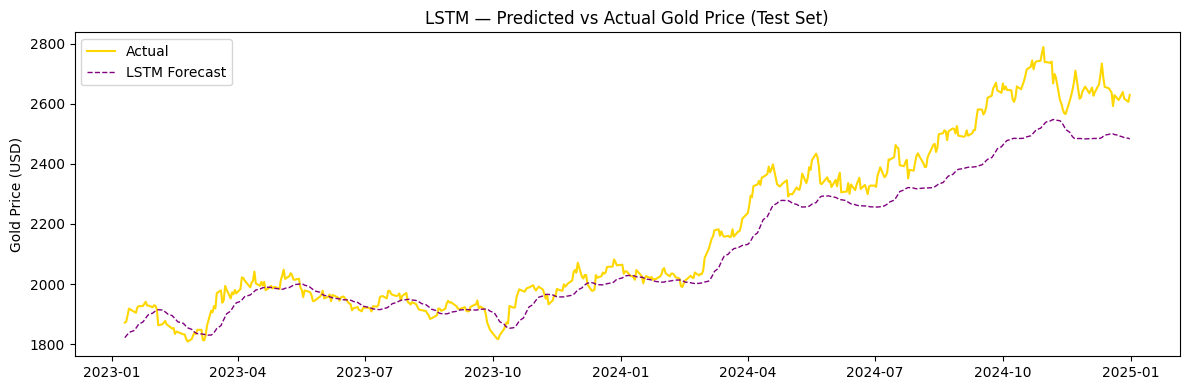

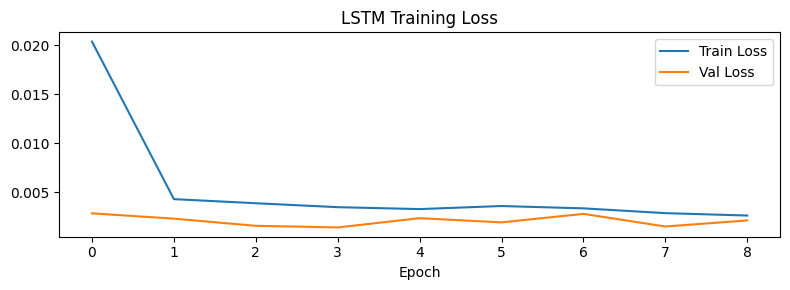

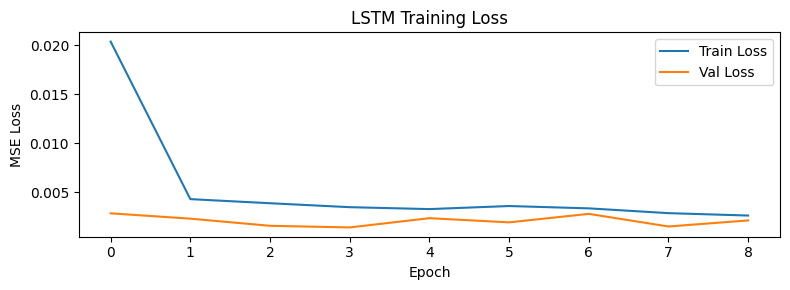

In [ ]:
# TESTING LSTM

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Scale only on training data to prevent leakage
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train[['Gold']])
test_scaled  = scaler.transform(test[['Gold']])

# Combine for sequence creation
all_scaled = np.concatenate([train_scaled, test_scaled])

# sequences of 60 days
SEQ_LEN = 60

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(all_scaled, SEQ_LEN)

# Split back into train/test
X_train_seq = X_all[:len(train)-SEQ_LEN]
y_train_seq = y_all[:len(train)-SEQ_LEN]
X_test_seq  = X_all[len(train)-SEQ_LEN:]
y_test_seq  = y_all[len(train)-SEQ_LEN:]

# Reshape for LSTM: (samples, timesteps, features)
X_train_seq = X_train_seq.reshape(-1, SEQ_LEN, 1)
X_test_seq  = X_test_seq.reshape(-1, SEQ_LEN, 1)

# Build LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# Train with early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Predict n inverse transform
lstm_preds_scaled = model.predict(X_test_seq)
lstm_preds = scaler.inverse_transform(lstm_preds_scaled)
y_test_actual = scaler.inverse_transform(y_test_seq.reshape(-1, 1))

# Evaluate
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_preds))
lstm_mae  = mean_absolute_error(y_test_actual, lstm_preds)
lstm_mape = np.mean(np.abs((y_test_actual - lstm_preds) / y_test_actual)) * 100

print(f"\n── LSTM Results ──")
print(f"RMSE: {lstm_rmse:.2f}")
print(f"MAE:  {lstm_mae:.2f}")
print(f"MAPE: {lstm_mape:.2f}%")

# plot
min_len = min(len(y_test_actual), len(lstm_preds))
test_dates = test.index[-min_len:]

plt.figure(figsize=(12, 4))
plt.plot(test_dates, y_test_actual[-min_len:], label='Actual', color='gold', linewidth=1.5)
plt.plot(test_dates, lstm_preds[-min_len:], label='LSTM Forecast', color='purple', linewidth=1, linestyle='--')
plt.title('LSTM — Predicted vs Actual Gold Price (Test Set)')
plt.ylabel('Gold Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_plot.png', dpi=150)
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_loss.png', dpi=150)
plt.show()

# Training loss curve
plt.figure(figsize=(8, 3))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_loss.png', dpi=150)
plt.show()